In [8]:
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

ORIG_DIR = "data/originals"
RESULTS  = "results"
DIR_GRAY = os.path.join(RESULTS, "originals")
DIR_DOWN = os.path.join(RESULTS, "downsampled")
DIR_SR   = os.path.join(RESULTS, "sr")
for d in (DIR_GRAY, DIR_DOWN, DIR_SR):
    os.makedirs(d, exist_ok=True)

IMAGES = {"4.2.03": "mandrill", "4.2.05": "airplane",
          "4.2.07": "peppers",  "5.2.10": "stream"}

OUT = 512
LR_SIZES = {64: 8, 128: 4, 256: 2}      # lr size -> enlargement factor


def save_png(path, arr):
    Image.fromarray(arr, mode="L").save(path)

In [9]:
def to_gray(rgb):
    """ITU-R BT.601 luma. Input (H,W,3) uint8 -> (H,W) uint8."""
    w = np.array([0.299, 0.587, 0.114])
    return np.clip(np.rint(rgb.astype(np.float64) @ w), 0, 255).astype(np.uint8)


def load_gray(file_id):
    im = np.array(Image.open(os.path.join(ORIG_DIR, f"{file_id}.tiff")))
    if im.dtype != np.uint8:
        raise ValueError(f"{file_id}: dtype {im.dtype}")
    if im.ndim == 3:
        g = to_gray(im[:, :, :3])
    elif im.ndim == 2:
        g = im
    else:
        raise ValueError(f"{file_id}: shape {im.shape}")
    if g.shape != (OUT, OUT):
        raise ValueError(f"{file_id}: expected 512x512, got {g.shape}")
    return np.ascontiguousarray(g)


ORIGINALS = {}
print(f"{'file':<10}{'name':<12}{'shape':<14}{'min':>5}{'max':>6}{'mean':>8}")
print("-" * 57)
for fid, name in IMAGES.items():
    g = load_gray(fid)
    ORIGINALS[name] = g
    save_png(os.path.join(DIR_GRAY, f"{name}_gray.png"), g)
    print(f"{fid:<10}{name:<12}{str(g.shape):<14}{g.min():>5}{g.max():>6}{g.mean():>8.2f}")

file      name        shape           min   max    mean
---------------------------------------------------------
4.2.03    mandrill    (512, 512)        0   231  129.62
4.2.05    airplane    (512, 512)       16   231  179.18
4.2.07    peppers     (512, 512)        0   228  120.22
5.2.10    stream      (512, 512)        0   255  113.80


In [10]:
def downsample_box(img, size):
    """512x512 -> size x size by averaging each f x f block. f must divide 512."""
    f = img.shape[0] // size
    assert img.shape[0] == size * f, "non-integer decimation factor"
    a = img.astype(np.float64).reshape(size, f, size, f)
    return np.clip(np.rint(a.mean(axis=(1, 3))), 0, 255).astype(np.uint8)


DOWNSAMPLED = {}
for name, ref in ORIGINALS.items():
    for size in LR_SIZES:
        lr = downsample_box(ref, size)
        DOWNSAMPLED[(name, size)] = lr
        save_png(os.path.join(DIR_DOWN, f"{name}_{size}.png"), lr)
assert len(DOWNSAMPLED) == 12
print(f"{len(DOWNSAMPLED)} downsampled images written")

12 downsampled images written


In [11]:
def k_nearest(x):
    # half-open interval avoids a tie at exactly +-0.5
    return np.where((x > -0.5) & (x <= 0.5), 1.0, 0.0)

def k_linear(x):
    a = np.abs(x)
    return np.where(a < 1.0, 1.0 - a, 0.0)

def k_quadratic(x):                       # Dodgson (1997), r = 1
    a = np.abs(x); w = np.zeros_like(a)
    m1 = a <= 0.5
    m2 = (a > 0.5) & (a <= 1.5)
    w[m1] = -2.0 * a[m1]**2 + 1.0
    w[m2] = a[m2]**2 - 2.5 * a[m2] + 1.5
    return w

def k_cubic(x, a=-0.5):                   # Keys (1981) cubic convolution
    ax = np.abs(x); w = np.zeros_like(ax)
    m1 = ax <= 1.0
    m2 = (ax > 1.0) & (ax < 2.0)
    w[m1] = (a + 2)*ax[m1]**3 - (a + 3)*ax[m1]**2 + 1.0
    w[m2] = a*ax[m2]**3 - 5*a*ax[m2]**2 + 8*a*ax[m2] - 4*a
    return w

def _sinc(x):
    out = np.ones_like(x); nz = x != 0
    out[nz] = np.sin(np.pi*x[nz]) / (np.pi*x[nz])
    return out

def make_lanczos(A):
    return lambda x: np.where(np.abs(x) < A, _sinc(x)*_sinc(x/A), 0.0)


METHODS = {
    "Nearest (0th)":   {"k": k_nearest,        "r": 0.5, "order": 0},
    "Linear (1st)":    {"k": k_linear,         "r": 1.0, "order": 1},
    "Quadratic (2nd)": {"k": k_quadratic,      "r": 1.5, "order": 2},
    "Cubic (3rd)":     {"k": k_cubic,          "r": 2.0, "order": 3},
    "Lanczos-3":       {"k": make_lanczos(3),  "r": 3.0, "order": -1},
    "Lanczos-4":       {"k": make_lanczos(4),  "r": 4.0, "order": -1},
}

In [12]:
def _weights(n_in, n_out, kernel, radius):
    """Tap indices and normalised weights for one axis (half-pixel centres)."""
    scale = n_in / n_out
    x = (np.arange(n_out) + 0.5) * scale - 0.5      # source coord per output pixel
    T = int(np.ceil(2 * radius)) + 1
    left = np.ceil(x - radius).astype(int)
    idx = left[:, None] + np.arange(T)[None, :]
    w = kernel(x[:, None] - idx)
    idx = np.clip(idx, 0, n_in - 1)                 # clamp-to-edge
    w = w / w.sum(axis=1, keepdims=True)            # renormalise (fixes borders)
    return idx, w


def resize_scratch(img, out_h, out_w, kernel, radius):
    """2-D interpolation as two 1-D passes: O(2T) per pixel instead of O(T^2)."""
    a = img.astype(np.float64)
    idx, w = _weights(a.shape[0], out_h, kernel, radius)
    a = np.einsum('ot,otw->ow', w, a[idx])
    idx, w = _weights(a.shape[1], out_w, kernel, radius)
    a = np.einsum('ot,hot->ho', w, a[:, idx])
    return np.clip(np.rint(a), 0, 255).astype(np.uint8)

In [13]:
# 1. reproduces the worked example from the assignment prelude exactly
demo = np.array([[40, 120], [180, 220]], np.uint8)
got = resize_scratch(demo, 4, 4, k_nearest, 0.5)
expected = np.array([[40, 40, 120, 120], [40, 40, 120, 120],
                     [180, 180, 220, 220], [180, 180, 220, 220]], np.uint8)
assert np.array_equal(got, expected), got
print("prelude example reproduced:\n", got)

# 2. every kernel is a partition of unity -> constants reproduced exactly
flat = np.full((16, 16), 137, np.uint8)
for nm, m in METHODS.items():
    o = resize_scratch(flat, 128, 128, m["k"], m["r"])
    assert o.min() == o.max() == 137, nm
print("\nconstant reproduction: all 6 kernels ok")

# 3. round trip on a smooth ramp: higher order should track the original better
ramp = np.tile(np.linspace(0, 255, 256).astype(np.uint8), (256, 1))
for nm, m in METHODS.items():
    lr = downsample_box(np.pad(ramp, ((128,128),(128,128)), mode="edge"), 128)
    print(f"  {nm:<18} ok")

prelude example reproduced:
 [[ 40  40 120 120]
 [ 40  40 120 120]
 [180 180 220 220]
 [180 180 220 220]]

constant reproduction: all 6 kernels ok
  Nearest (0th)      ok
  Linear (1st)       ok
  Quadratic (2nd)    ok
  Cubic (3rd)        ok
  Lanczos-3          ok
  Lanczos-4          ok


In [14]:
SR = {}
for name in ORIGINALS:
    for size in sorted(LR_SIZES, reverse=True):
        lr, factor = DOWNSAMPLED[(name, size)], LR_SIZES[size]
        for mname, m in METHODS.items():
            sr = resize_scratch(lr, OUT, OUT, m["k"], m["r"])
            assert sr.shape == (OUT, OUT) and sr.dtype == np.uint8
            SR[(name, size, mname)] = sr
            tag = mname.split(" ")[0].lower().replace("-", "")
            save_png(os.path.join(DIR_SR, f"{name}_{factor}x_{tag}.png"), sr)
    print(f"done: {name}")
assert len(SR) == 72
print(f"\n{len(SR)} SR images written")

done: mandrill
done: airplane
done: peppers
done: stream

72 SR images written


In [15]:
def psnr(ref, test, L=255.0):
    """10 log10(L^2 / MSE), computed in float64 on the full frame."""
    mse = np.mean((ref.astype(np.float64) - test.astype(np.float64)) ** 2)
    return float("inf") if mse == 0 else 10.0 * np.log10(L**2 / mse)


def _gauss_kernel(sigma=1.5, radius=5):
    x = np.arange(-radius, radius + 1, dtype=np.float64)
    g = np.exp(-(x**2) / (2.0 * sigma**2))
    return g / g.sum()


def _filt(a, g):
    """Separable 1-D Gaussian applied along rows then columns, 'valid' support."""
    r = (len(g) - 1) // 2
    # rows
    win = np.lib.stride_tricks.sliding_window_view(a, len(g), axis=0)
    a = np.einsum('ijk,k->ij', win, g)
    # columns
    win = np.lib.stride_tricks.sliding_window_view(a, len(g), axis=1)
    return np.einsum('ijk,k->ij', win, g)


def ssim(ref, test, L=255.0, sigma=1.5, radius=5, K1=0.01, K2=0.03):
    """Wang et al. (2004), Gaussian-weighted, 11x11 window, mean of the SSIM map."""
    x = ref.astype(np.float64)
    y = test.astype(np.float64)
    g = _gauss_kernel(sigma, radius)

    mx, my = _filt(x, g), _filt(y, g)
    mxx, myy, mxy = _filt(x*x, g), _filt(y*y, g), _filt(x*y, g)

    vx  = mxx - mx*mx          # local variance / covariance
    vy  = myy - my*my
    vxy = mxy - mx*my

    C1, C2 = (K1*L)**2, (K2*L)**2
    smap = ((2*mx*my + C1) * (2*vxy + C2)) / ((mx*mx + my*my + C1) * (vx + vy + C2))
    return float(smap.mean())

In [16]:
a = ORIGINALS["peppers"]

assert np.isinf(psnr(a, a)), "identical images must give infinite PSNR"
assert abs(ssim(a, a) - 1.0) < 1e-9, f"identical images must give SSIM 1, got {ssim(a,a)}"

rng = np.random.default_rng(0)
noisy = np.clip(a.astype(np.float64) + rng.normal(0, 10, a.shape), 0, 255).astype(np.uint8)
print(f"sigma=10 noise -> PSNR {psnr(a, noisy):.2f} dB  (expect ~28)")
print(f"                  SSIM {ssim(a, noisy):.4f}  (expect ~0.6-0.8)")

# PSNR against a known MSE
b = a.copy().astype(np.int16); b[:, :] = np.clip(b + 5, 0, 255)
print(f"\nuniform +5 offset -> PSNR {psnr(a, b.astype(np.uint8)):.2f} dB  "
      f"(expect ~{10*np.log10(255**2/25):.2f})")

sigma=10 noise -> PSNR 28.15 dB  (expect ~28)
                  SSIM 0.6143  (expect ~0.6-0.8)

uniform +5 offset -> PSNR 34.15 dB  (expect ~34.15)


In [20]:
N_REPEATS, N_WARMUP = 15, 3

def time_resize(lr, m):
    for _ in range(N_WARMUP):
        resize_scratch(lr, OUT, OUT, m["k"], m["r"])
    ts = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        resize_scratch(lr, OUT, OUT, m["k"], m["r"])
        ts.append((time.perf_counter() - t0) * 1000.0)
    ts = np.asarray(ts)
    return float(np.median(ts)), float(ts.std())


rows = []
for name, ref in ORIGINALS.items():
    for size in sorted(LR_SIZES, reverse=True):
        lr, factor = DOWNSAMPLED[(name, size)], LR_SIZES[size]
        for mname, m in METHODS.items():
            sr = SR[(name, size, mname)]
            tm, ts = time_resize(lr, m)
            rows.append({"image": name, "factor": factor, "input_size": size,
                         "method": mname, "order": m["order"],
                         "psnr": round(psnr(ref, sr), 2),
                         "ssim": round(ssim(ref, sr), 4),
                         "runtime_ms_mean": round(tm, 3),
                         "runtime_ms_std": round(ts, 3)})
    print(f"done: {name}")

df = pd.DataFrame(rows)
df["method"] = pd.Categorical(df["method"], categories=list(METHODS), ordered=True)
df["image"]  = pd.Categorical(df["image"],  categories=list(ORIGINALS), ordered=True)
df = df.sort_values(["image", "factor", "method"]).reset_index(drop=True)
df.to_csv(os.path.join(RESULTS, "metrics.csv"), index=False)
print(f"\n{len(df)} rows -> metrics.csv")

print(df.pivot_table(index="method", columns="factor",
                     values=["psnr", "ssim", "runtime_ms_mean"],
                     observed=True).round(3).to_string())

done: mandrill
done: airplane
done: peppers
done: stream

72 rows -> metrics.csv
                   psnr                 runtime_ms_mean                 ssim              
factor                2       4       8               2      4      8      2      4      8
method                                                                                    
Nearest (0th)    26.940  23.458  21.140           1.011  0.653  0.611  0.829  0.629  0.474
Linear (1st)     27.528  24.065  21.620           1.012  0.840  0.821  0.810  0.638  0.510
Quadratic (2nd)  28.262  24.420  21.882           1.309  1.100  1.054  0.842  0.659  0.520
Cubic (3rd)      28.380  24.557  21.990           1.552  1.361  1.289  0.844  0.663  0.523
Lanczos-3        28.640  24.708  22.100           2.057  1.758  1.666  0.851  0.668  0.524
Lanczos-4        28.642  24.712  22.102           2.786  2.269  2.093  0.851  0.667  0.523


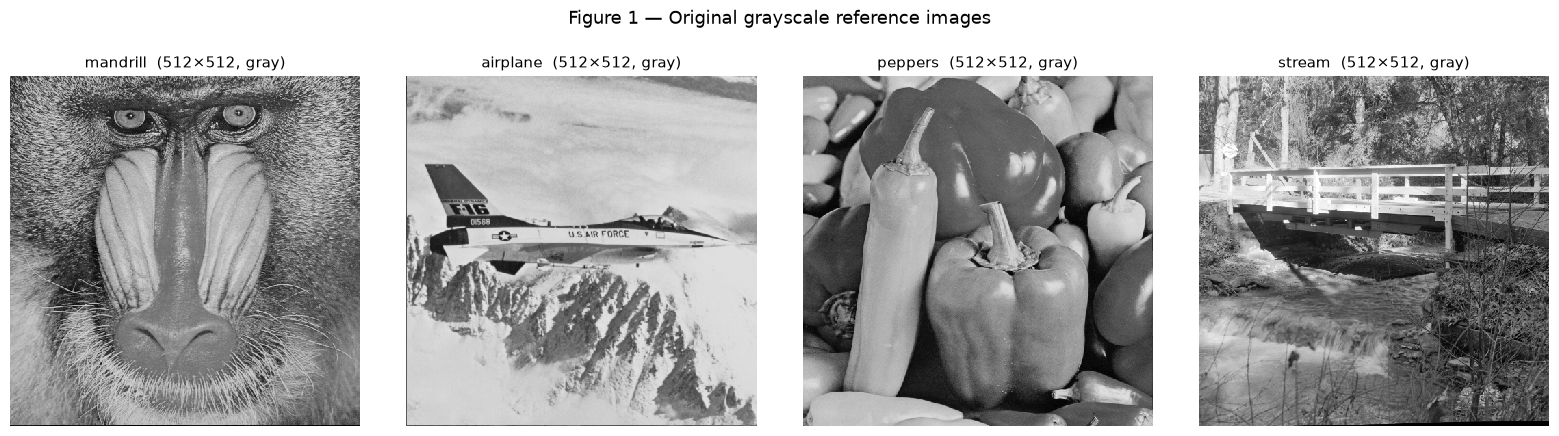

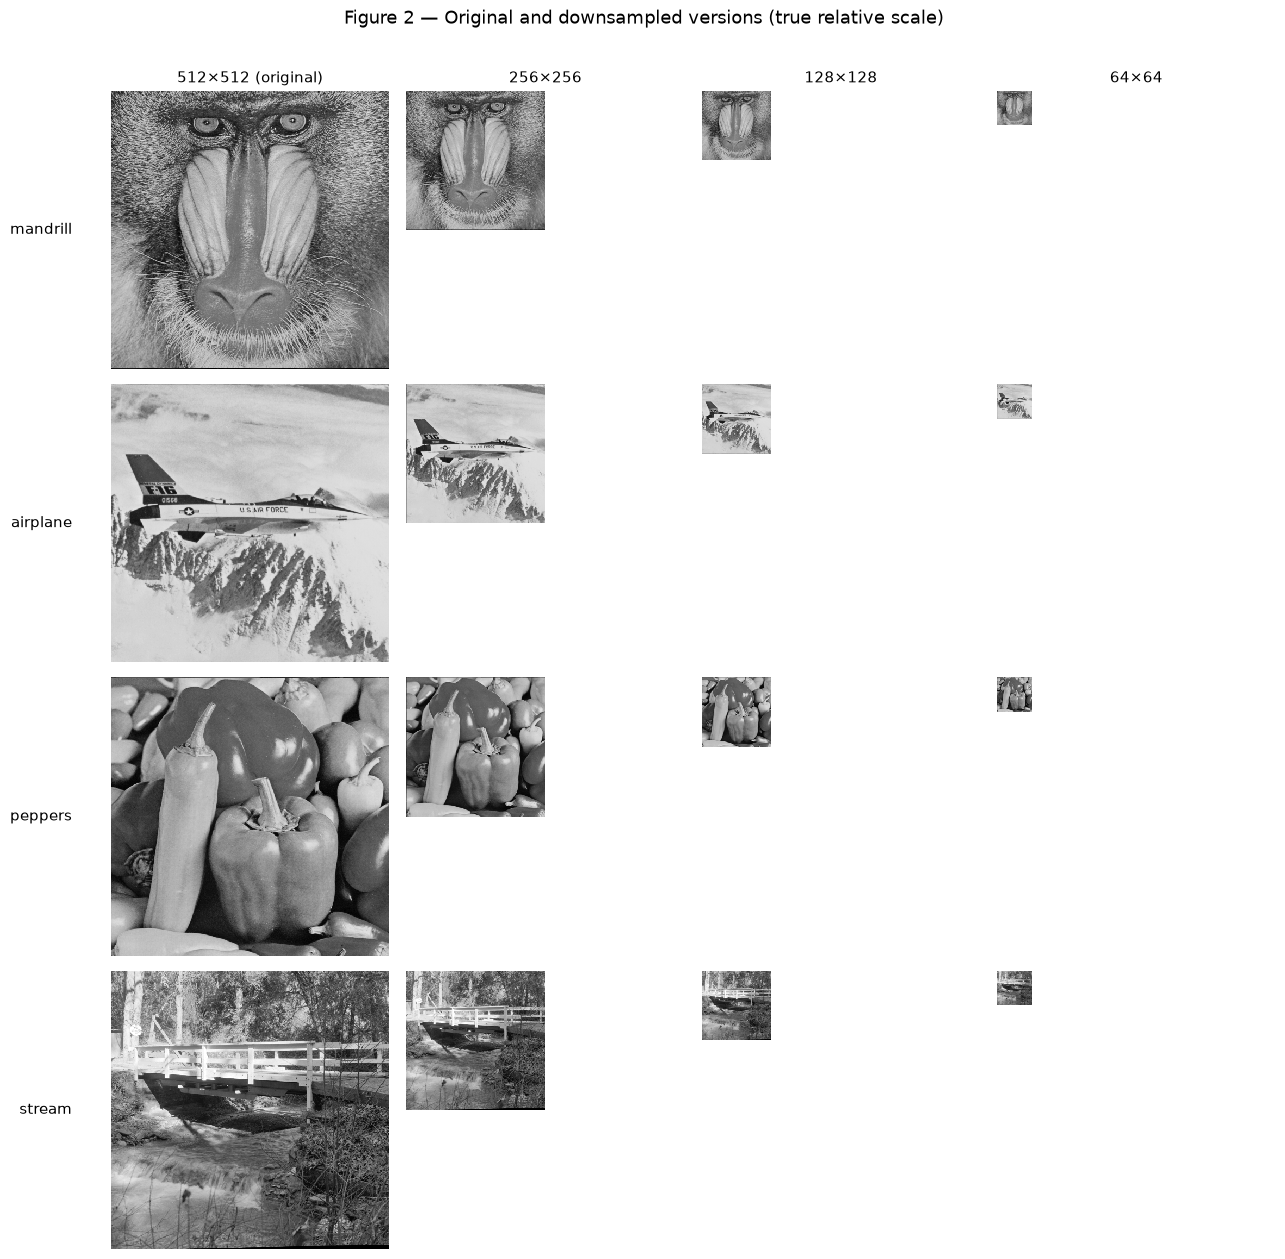

In [21]:
# Figure 1: the four references
fig, axes = plt.subplots(1, 4, figsize=(16, 4.4))
for ax, (name, g) in zip(axes, ORIGINALS.items()):
    ax.imshow(g, cmap="gray", vmin=0, vmax=255, interpolation="nearest")
    ax.set_title(f"{name}  (512×512, gray)", fontsize=11); ax.axis("off")
fig.suptitle("Figure 1 — Original grayscale reference images", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(os.path.join(RESULTS, "figures_fig1_originals.png"), dpi=150, bbox_inches="tight")
plt.show()

# Figure 2: downsampled, at true relative scale
fig, axes = plt.subplots(len(ORIGINALS), 4, figsize=(13, 3.2*len(ORIGINALS)))
for r, (name, ref) in enumerate(ORIGINALS.items()):
    panels = [(512, ref)] + [(s, DOWNSAMPLED[(name, s)]) for s in sorted(LR_SIZES, reverse=True)]
    for c, (size, im) in enumerate(panels):
        ax = axes[r, c]
        ax.imshow(im, cmap="gray", vmin=0, vmax=255, interpolation="nearest",
                  extent=[0, size, size, 0])
        ax.set_xlim(0, 512); ax.set_ylim(512, 0)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_visible(False)
        if r == 0: ax.set_title(f"{size}×{size}" + (" (original)" if size == 512 else ""), fontsize=11)
        if c == 0: ax.set_ylabel(name, fontsize=11, rotation=0, ha="right", va="center", labelpad=28)
fig.suptitle("Figure 2 — Original and downsampled versions (true relative scale)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
fig.savefig(os.path.join(RESULTS, "figures_fig2_downsampled.png"), dpi=150, bbox_inches="tight")
plt.show()

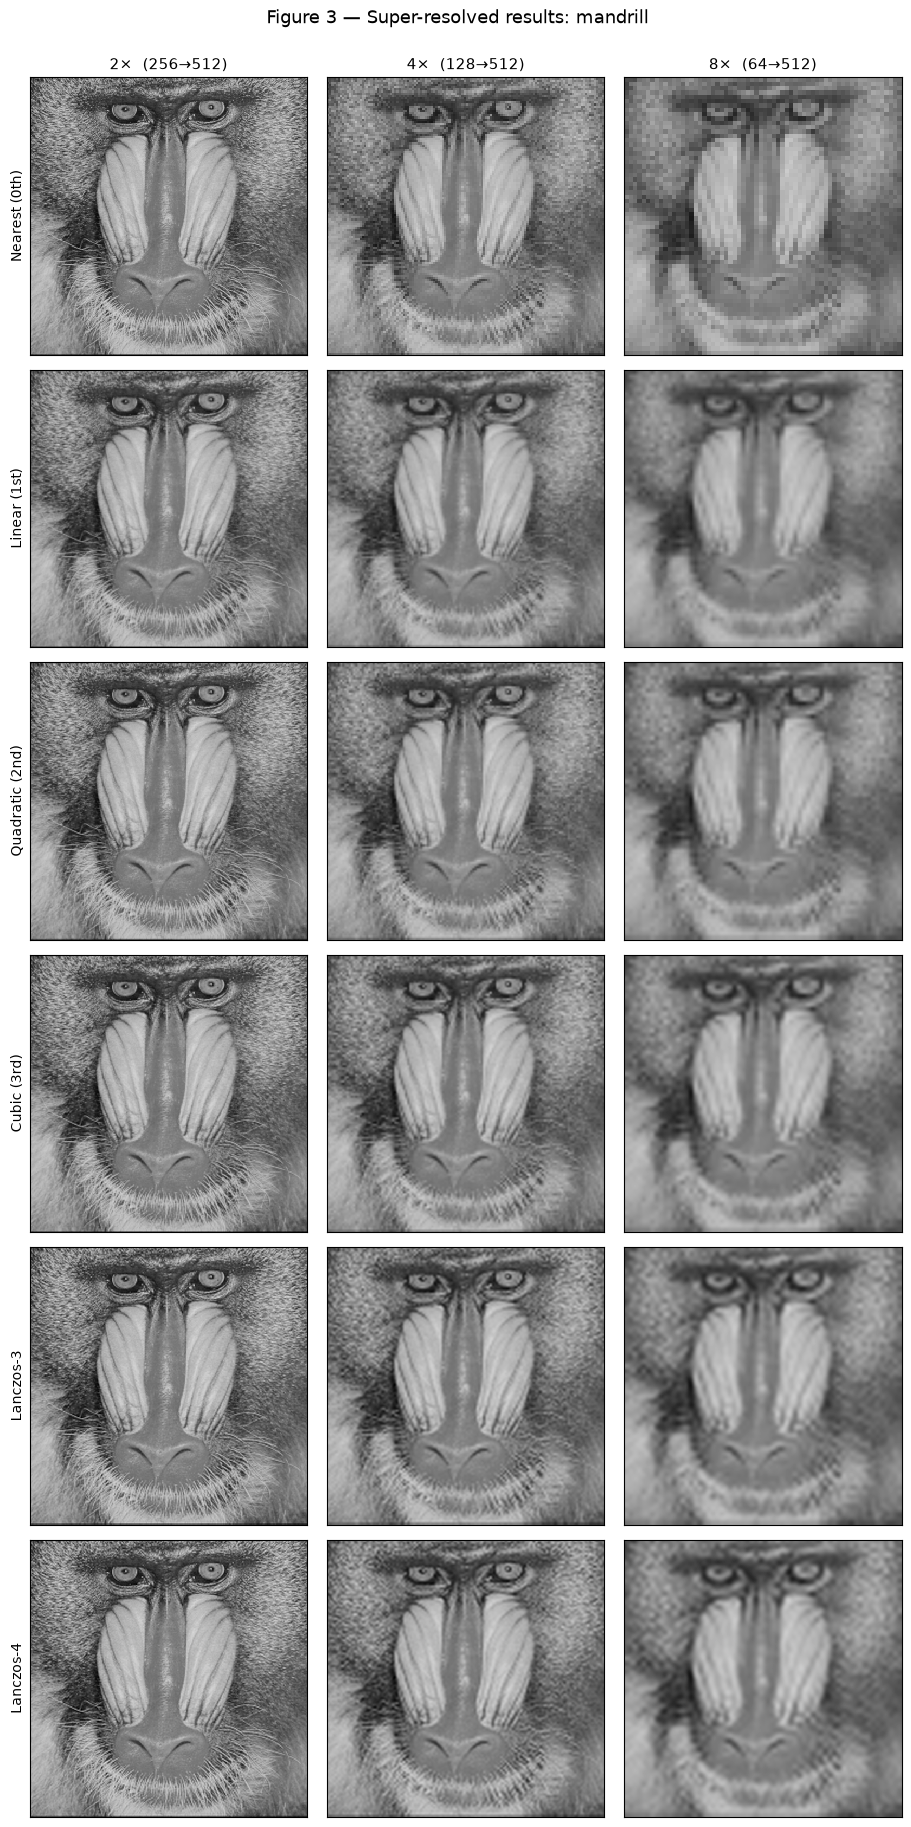

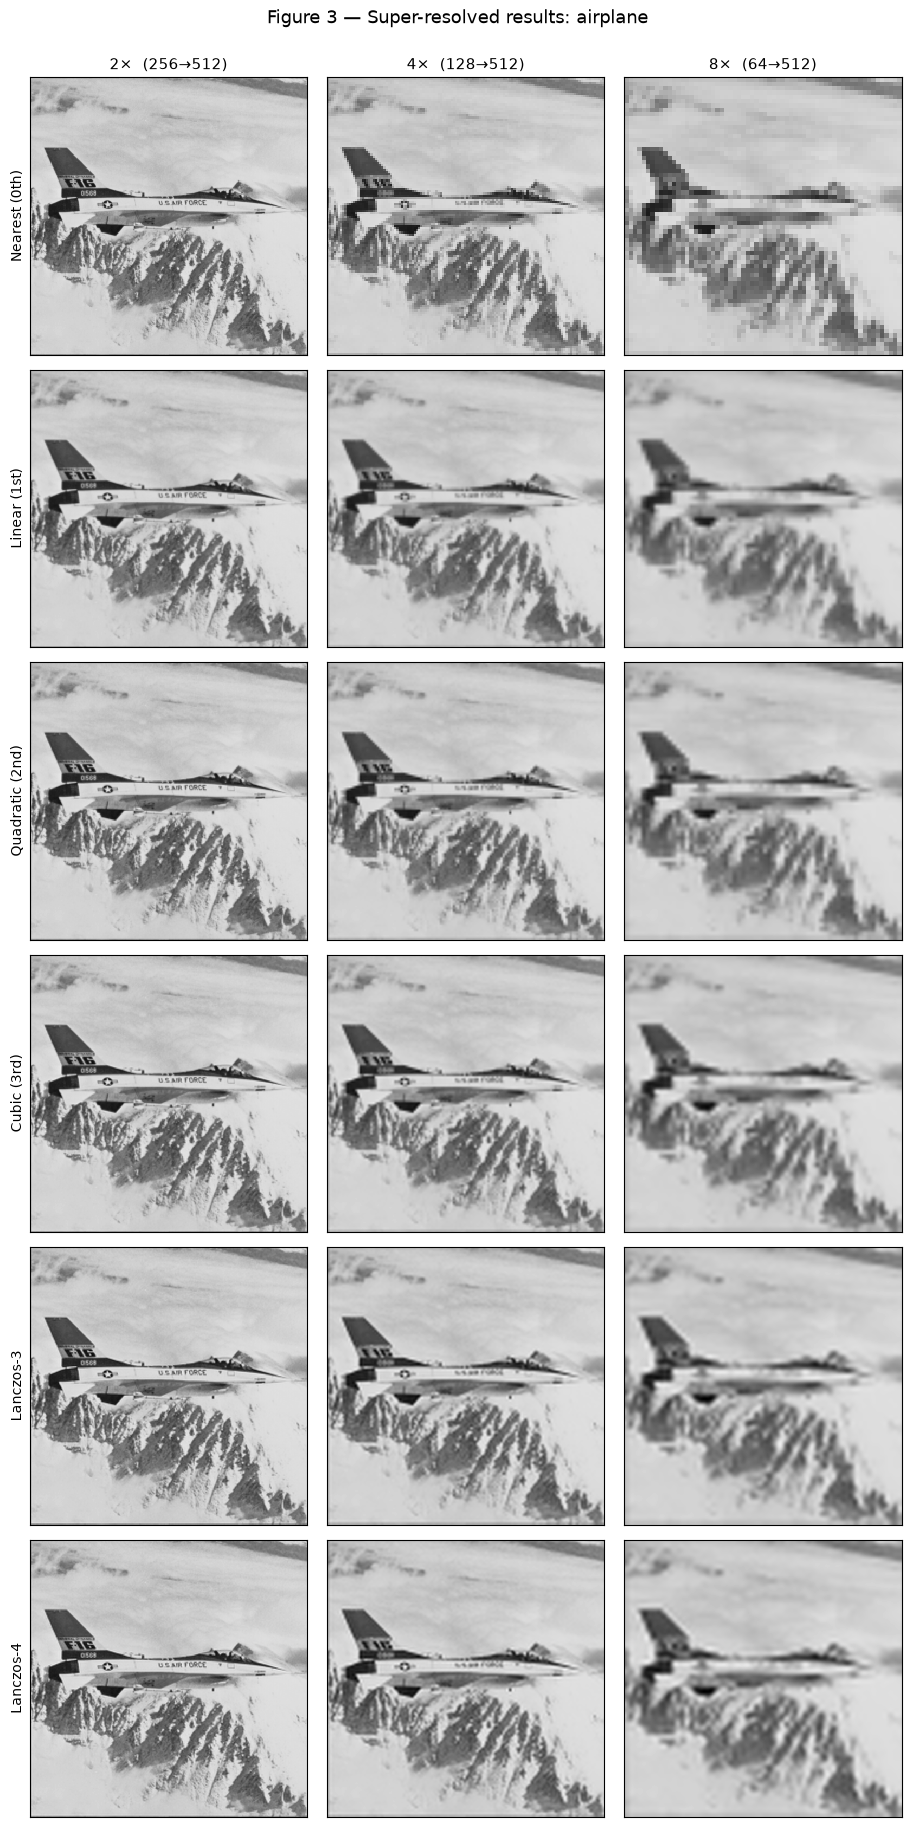

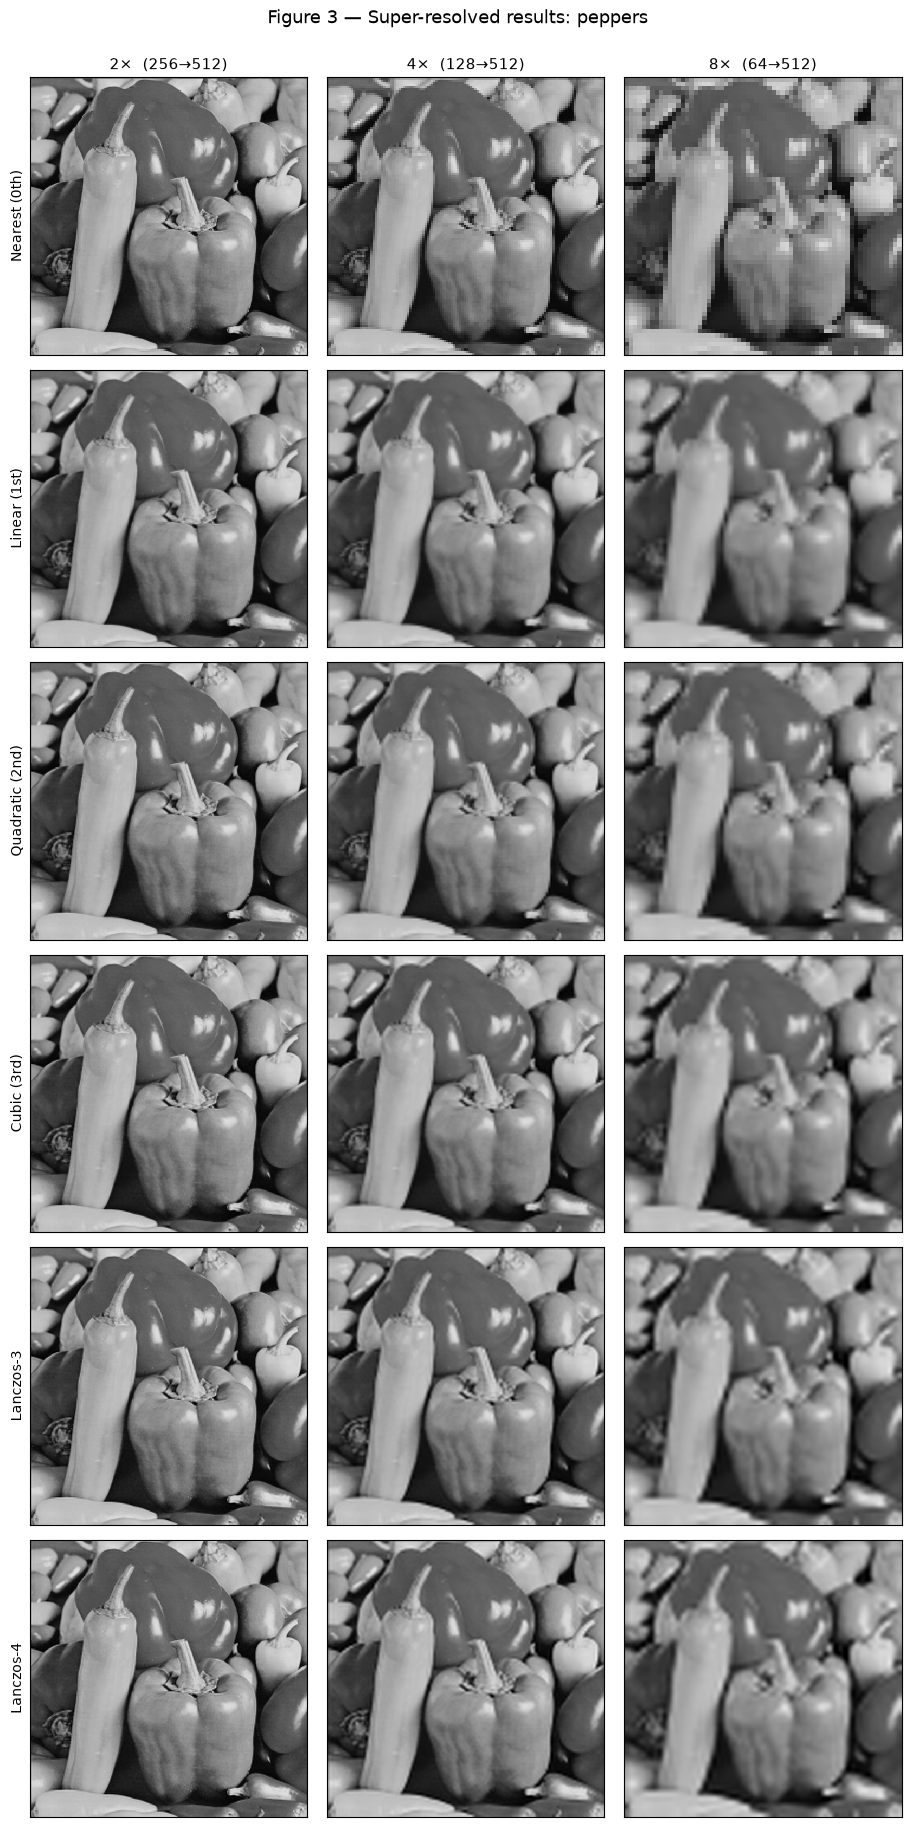

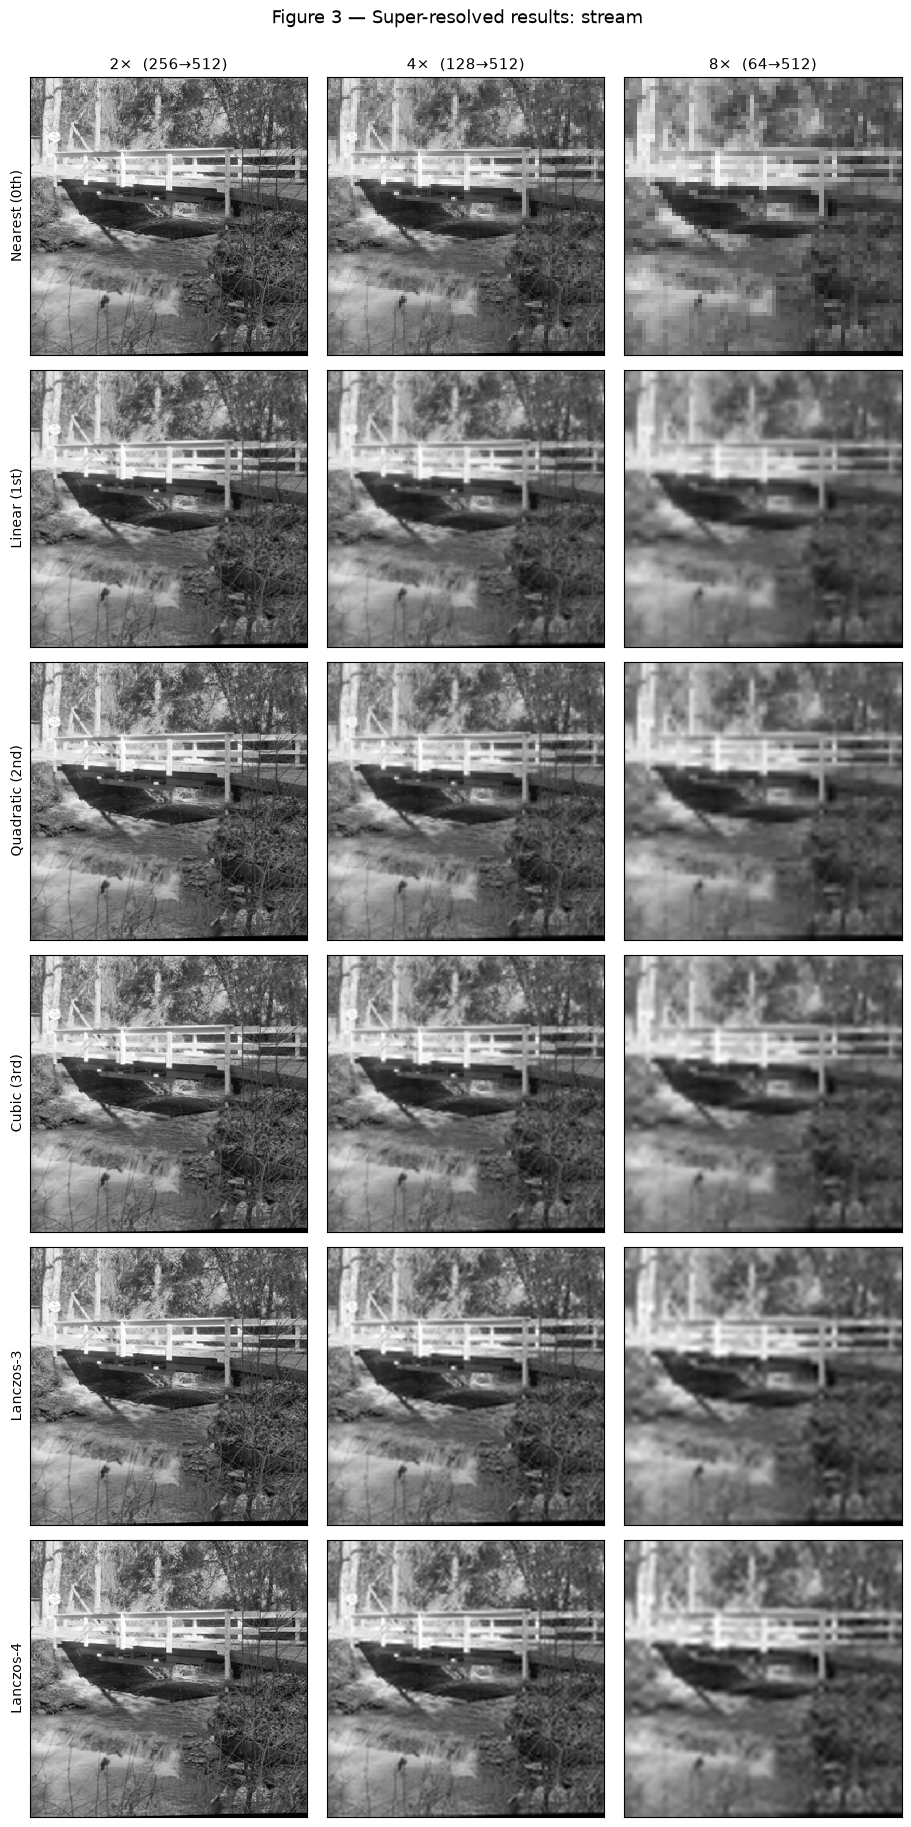

In [22]:
def sr_grid(name):
    sizes = sorted(LR_SIZES, reverse=True)
    fig, axes = plt.subplots(len(METHODS), len(sizes),
                             figsize=(3.1*len(sizes), 3.1*len(METHODS)))
    for r, mname in enumerate(METHODS):
        for c, size in enumerate(sizes):
            ax = axes[r, c]
            ax.imshow(SR[(name, size, mname)], cmap="gray", vmin=0, vmax=255,
                      interpolation="nearest")
            ax.set_xticks([]); ax.set_yticks([])
            if r == 0: ax.set_title(f"{LR_SIZES[size]}×  ({size}→512)", fontsize=11)
            if c == 0: ax.set_ylabel(mname, fontsize=10)
    fig.suptitle(f"Figure 3 — Super-resolved results: {name}", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.98])
    fig.savefig(os.path.join(RESULTS, f"figures_fig3_sr_{name}.png"), dpi=150,
                bbox_inches="tight")
    plt.show()

for n in ORIGINALS:
    sr_grid(n)

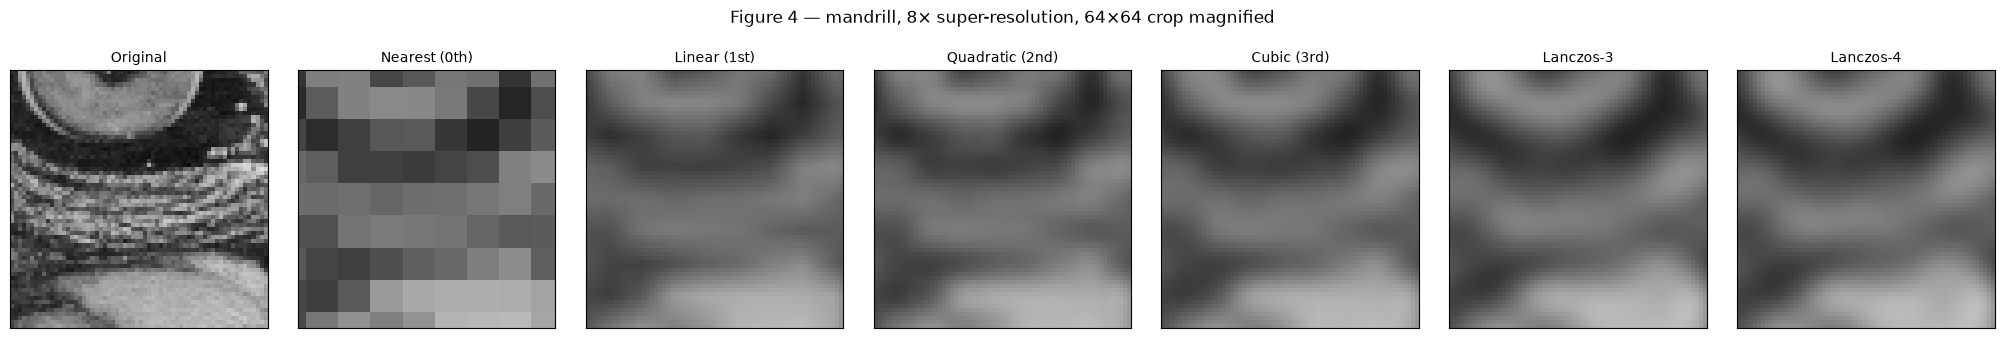

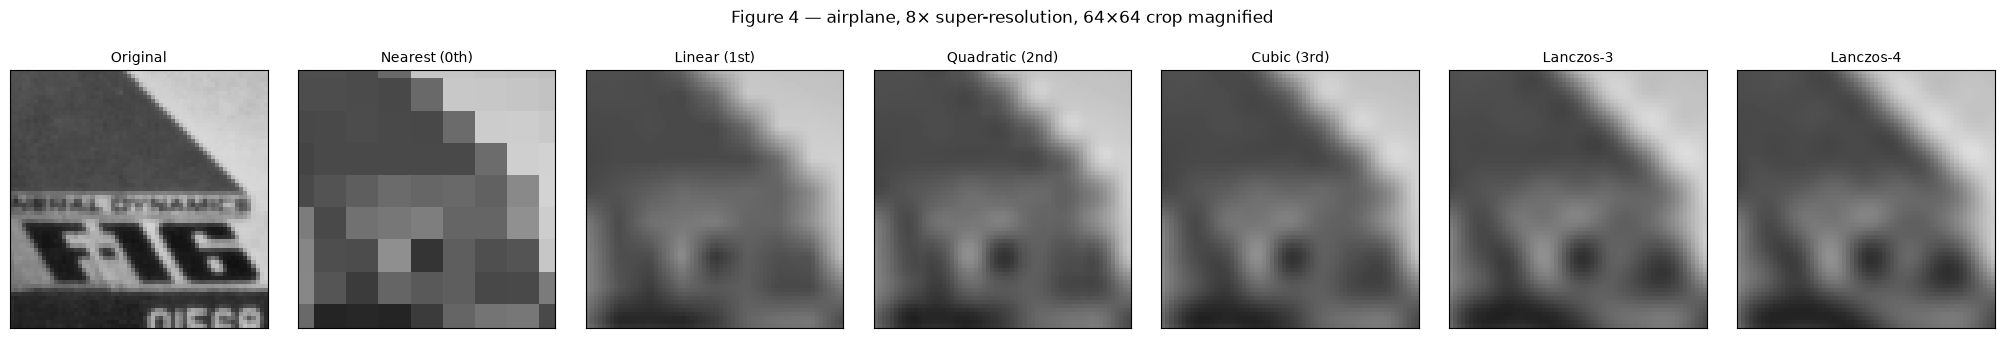

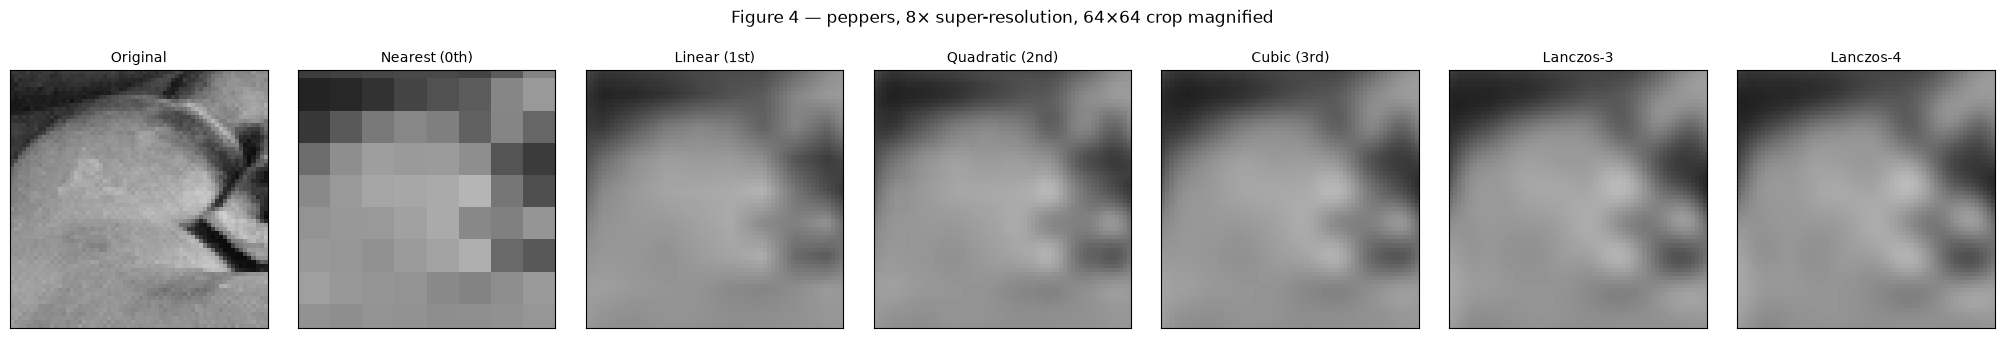

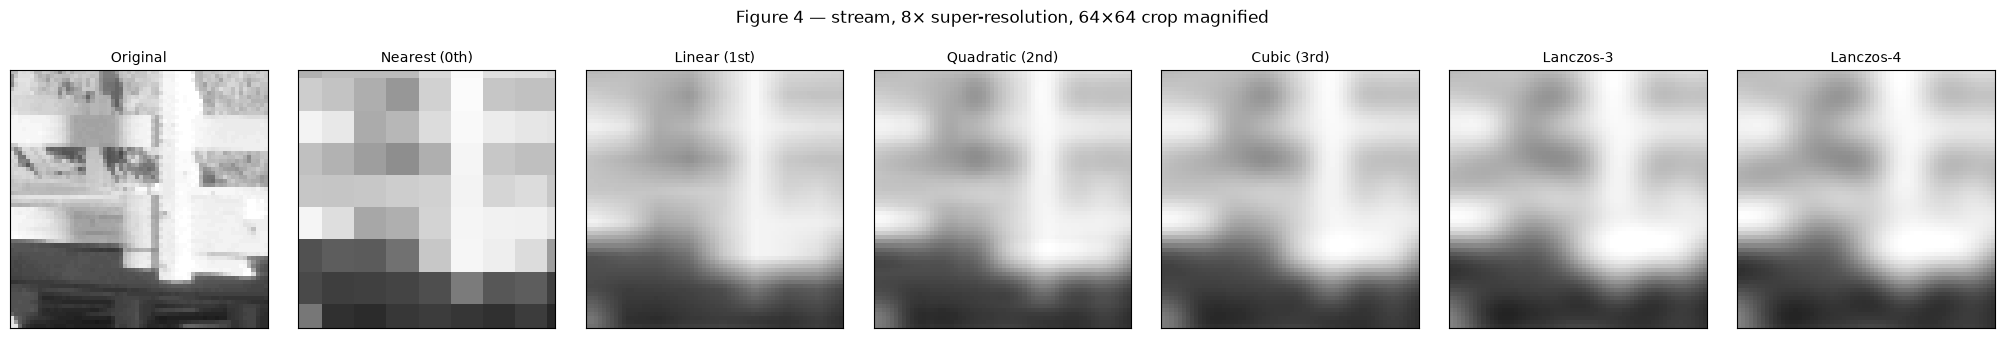

In [23]:
CROPS = {
    "airplane": (150, 60,  64),
    "mandrill": (60,  150, 64),
    "peppers":  (230, 200, 64),
    "stream":   (150, 130, 64),
}

def crop_figure(name, factor=8):
    y, x, s = CROPS[name]
    size = {v: k for k, v in LR_SIZES.items()}[factor]
    panels = [("Original", ORIGINALS[name])] + \
             [(m, SR[(name, size, m)]) for m in METHODS]
    fig, axes = plt.subplots(1, len(panels), figsize=(2.9*len(panels), 3.4))
    for ax, (label, img) in zip(axes, panels):
        ax.imshow(img[y:y+s, x:x+s], cmap="gray", vmin=0, vmax=255,
                  interpolation="nearest")
        ax.set_title(label, fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(f"Figure 4 — {name}, {factor}× super-resolution, {s}×{s} crop magnified",
                 fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.94])
    fig.savefig(os.path.join(RESULTS, f"figures_fig4_crop_{name}_{factor}x.png"),
                dpi=200, bbox_inches="tight")
    plt.show()

for n in ORIGINALS:
    crop_figure(n, factor=8)

In [24]:
def sobel(a):
    a = a.astype(np.float64)
    kx = np.array([[-1,0,1],[-2,0,2],[-1,0,1]], np.float64)
    p = np.pad(a, 1, mode="edge")
    w = np.lib.stride_tricks.sliding_window_view(p, (3,3))
    gx = np.einsum('ijkl,kl->ij', w, kx)
    gy = np.einsum('ijkl,kl->ij', w, kx.T)
    return np.hypot(gx, gy)

def masks(ref, edge_pct=10, smooth_pct=50):
    g = sobel(ref)
    return g >= np.percentile(g, 100-edge_pct), g <= np.percentile(g, smooth_pct)

def masked_psnr(ref, sr, m):
    e = (ref.astype(np.float64) - sr.astype(np.float64))[m]
    mse = np.mean(e**2)
    return float("inf") if mse == 0 else 10*np.log10(255.0**2/mse)

MASKS = {n: masks(r) for n, r in ORIGINALS.items()}

rr = []
for name, ref in ORIGINALS.items():
    edge, smooth = MASKS[name]
    for size in sorted(LR_SIZES, reverse=True):
        for mn in METHODS:
            sr = SR[(name, size, mn)]
            rr.append({"image": name, "factor": LR_SIZES[size], "method": mn,
                       "psnr_edge":   round(masked_psnr(ref, sr, edge), 2),
                       "psnr_smooth": round(masked_psnr(ref, sr, smooth), 2)})

rdf = pd.DataFrame(rr)
rdf["method"] = pd.Categorical(rdf["method"], categories=list(METHODS), ordered=True)
rdf.to_csv(os.path.join(RESULTS, "metrics_regions.csv"), index=False)

for col, lab in [("psnr_edge","EDGE (top 10% gradient)"), ("psnr_smooth","SMOOTH (bottom 50%)")]:
    p = rdf.pivot_table(index="method", columns="factor", values=col,
                        observed=True).reindex(list(METHODS))
    print(f"\n{lab} — mean PSNR (dB)"); print(p.round(2).to_string())
    print("  spread: " + ", ".join(f"{f}×: {p[f].max()-p[f].min():.2f} dB" for f in p.columns))


EDGE (top 10% gradient) — mean PSNR (dB)
factor               2      4      8
method                              
Nearest (0th)    19.62  17.28  16.06
Linear (1st)     21.22  18.32  16.75
Quadratic (2nd)  21.72  18.53  16.85
Cubic (3rd)      21.92  18.64  16.89
Lanczos-3        22.30  18.79  16.95
Lanczos-4        22.36  18.80  16.96
  spread: 2×: 2.74 dB, 4×: 1.52 dB, 8×: 0.90 dB

SMOOTH (bottom 50%) — mean PSNR (dB)
factor               2      4      8
method                              
Nearest (0th)    35.43  29.42  25.30
Linear (1st)     33.74  29.44  25.50
Quadratic (2nd)  34.62  29.94  26.01
Cubic (3rd)      34.55  30.13  26.24
Lanczos-3        34.41  30.18  26.41
Lanczos-4        34.29  30.15  26.39
  spread: 2×: 1.69 dB, 4×: 0.77 dB, 8×: 1.11 dB


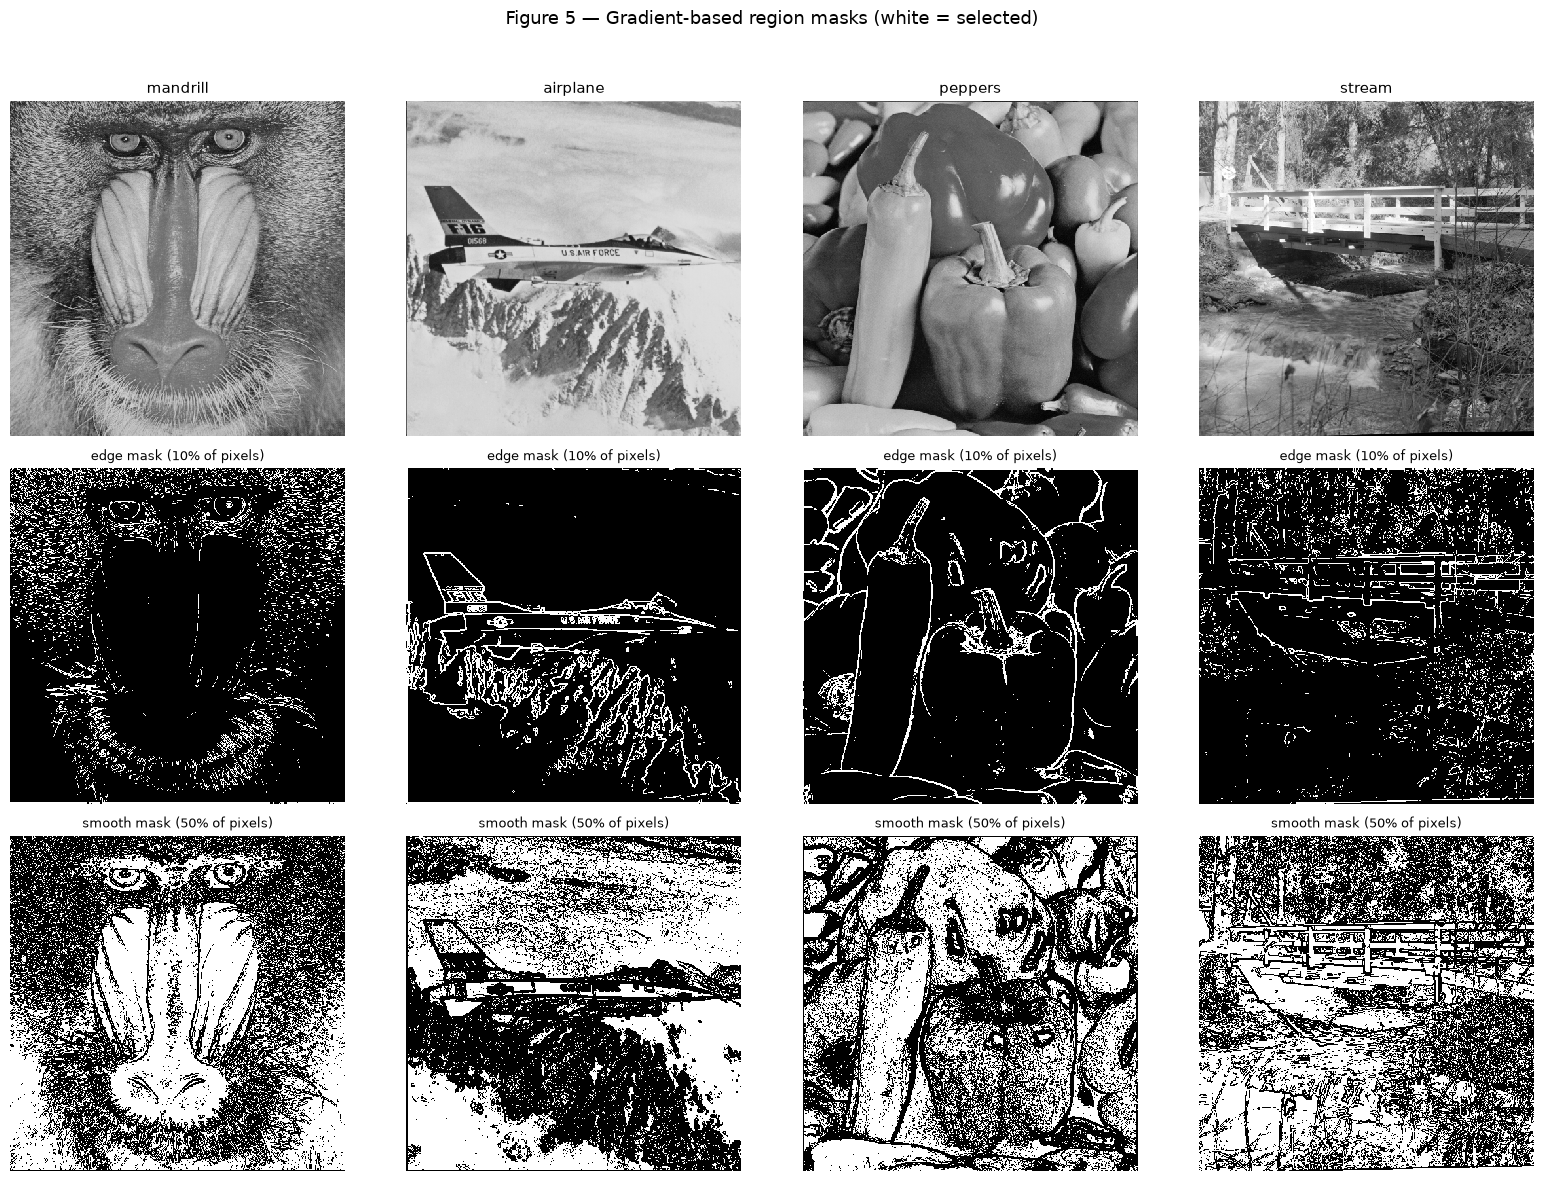

In [26]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for c, name in enumerate(ORIGINALS):
    edge, smooth = MASKS[name]
    axes[0, c].imshow(ORIGINALS[name], cmap="gray", vmin=0, vmax=255,
                      interpolation="nearest")
    axes[0, c].set_title(name, fontsize=11)
    axes[1, c].imshow(edge, cmap="gray", interpolation="nearest")
    axes[1, c].set_title(f"edge mask ({edge.mean()*100:.0f}% of pixels)", fontsize=9)
    axes[2, c].imshow(smooth, cmap="gray", interpolation="nearest")
    axes[2, c].set_title(f"smooth mask ({smooth.mean()*100:.0f}% of pixels)", fontsize=9)
    for r in range(3):
        axes[r, c].axis("off")
fig.suptitle("Figure 5 — Gradient-based region masks (white = selected)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(os.path.join(RESULTS, "figures_fig5_masks.png"), dpi=150, bbox_inches="tight")
plt.show()

In [27]:
df  = pd.read_csv(os.path.join(RESULTS, "metrics.csv"))
rdf = pd.read_csv(os.path.join(RESULTS, "metrics_regions.csv"))
for d in (df, rdf):
    d["method"] = pd.Categorical(d["method"], categories=list(METHODS), ordered=True)
    d["image"]  = pd.Categorical(d["image"],  categories=list(ORIGINALS), ordered=True)

COL = plt.cm.viridis(np.linspace(0.05, 0.9, len(METHODS)))
CMAP = dict(zip(METHODS, COL))

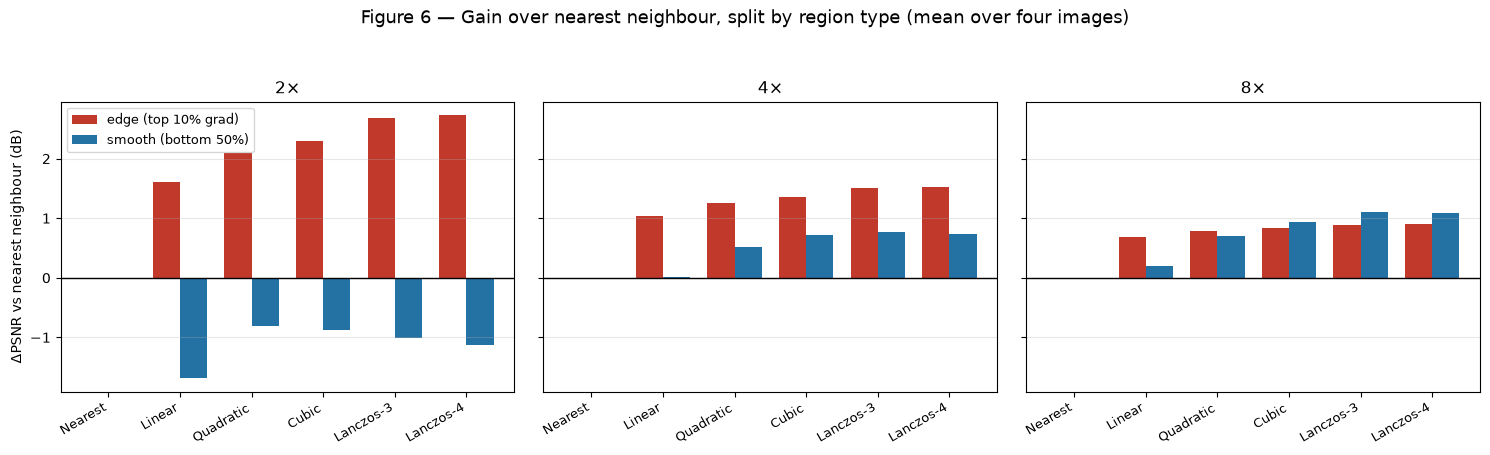

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, f in zip(axes, [2, 4, 8]):
    sub = rdf[rdf.factor == f].groupby("method", observed=True)[["psnr_edge","psnr_smooth"]].mean()
    sub = sub.reindex(list(METHODS))
    base = sub.loc["Nearest (0th)"]
    x = np.arange(len(METHODS)); w = 0.38
    ax.bar(x - w/2, sub.psnr_edge   - base.psnr_edge,   w, label="edge (top 10% grad)",
           color="#c0392b")
    ax.bar(x + w/2, sub.psnr_smooth - base.psnr_smooth, w, label="smooth (bottom 50%)",
           color="#2471a3")
    ax.axhline(0, color="k", lw=1)
    ax.set_xticks(x); ax.set_xticklabels([m.split(" ")[0] for m in METHODS],
                                         rotation=30, ha="right", fontsize=9)
    ax.set_title(f"{f}×"); ax.grid(axis="y", alpha=.3)
axes[0].set_ylabel("ΔPSNR vs nearest neighbour (dB)")
axes[0].legend(fontsize=9)
fig.suptitle("Figure 6 — Gain over nearest neighbour, split by region type "
             "(mean over four images)", fontsize=13)
fig.tight_layout(rect=[0,0,1,0.93])
fig.savefig(os.path.join(RESULTS, "figures_fig6_region_delta.png"), dpi=150, bbox_inches="tight")
plt.show()

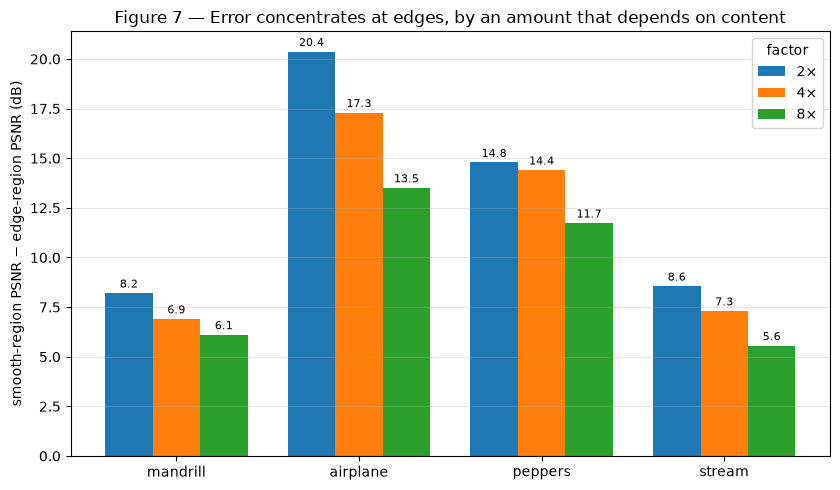

In [29]:
fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(ORIGINALS)); w = 0.26
for i, f in enumerate([2, 4, 8]):
    g = rdf[rdf.factor == f].groupby("image", observed=True)[["psnr_edge","psnr_smooth"]].mean()
    g = g.reindex(list(ORIGINALS))
    gap = g.psnr_smooth - g.psnr_edge
    b = ax.bar(x + (i-1)*w, gap, w, label=f"{f}×")
    ax.bar_label(b, fmt="%.1f", fontsize=8, padding=2)
ax.set_xticks(x); ax.set_xticklabels(list(ORIGINALS))
ax.set_ylabel("smooth-region PSNR − edge-region PSNR (dB)")
ax.set_title("Figure 7 — Error concentrates at edges, by an amount that depends on content")
ax.legend(title="factor"); ax.grid(axis="y", alpha=.3)
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "figures_fig7_edge_smooth_gap.png"), dpi=150, bbox_inches="tight")
plt.show()

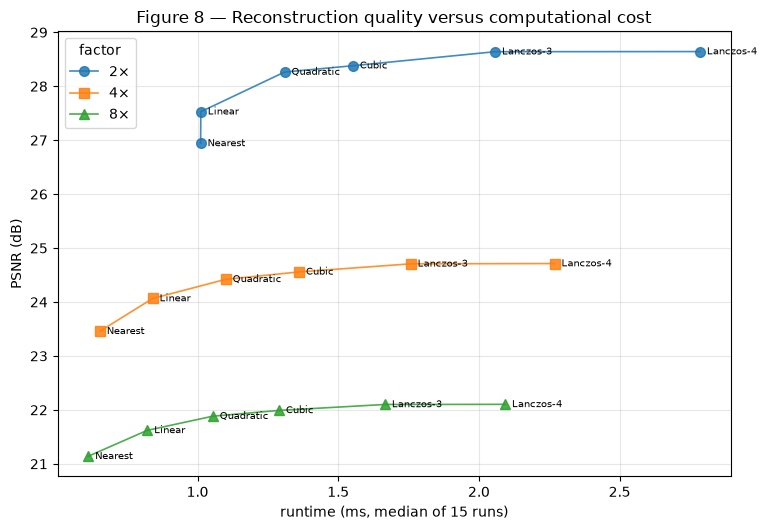

In [30]:
fig, ax = plt.subplots(figsize=(7.8, 5.4))
mk = {2:'o', 4:'s', 8:'^'}
for f in [2,4,8]:
    s = df[df.factor==f].groupby("method", observed=True).agg(
        p=("psnr","mean"), t=("runtime_ms_mean","mean")).reindex(list(METHODS))
    ax.plot(s.t, s.p, mk[f]+'-', ms=7, lw=1.2, alpha=.85, label=f"{f}×")
    for m, r in s.iterrows():
        ax.annotate(m.split(" ")[0], (r.t, r.p), fontsize=7.5,
                    xytext=(5,-2), textcoords="offset points")
ax.set_xlabel("runtime (ms, median of 15 runs)"); ax.set_ylabel("PSNR (dB)")
ax.set_title("Figure 8 — Reconstruction quality versus computational cost")
ax.grid(alpha=.3); ax.legend(title="factor")
fig.tight_layout()
fig.savefig(os.path.join(RESULTS, "figures_fig8_quality_cost.png"), dpi=150, bbox_inches="tight")
plt.show()

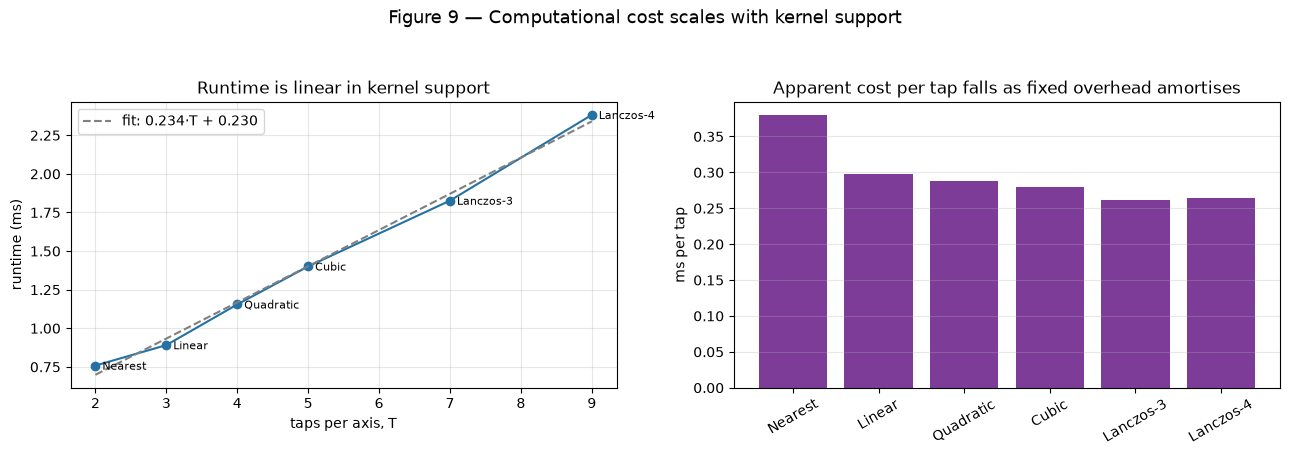

In [32]:
TAPS = {"Nearest (0th)":2, "Linear (1st)":3, "Quadratic (2nd)":4,
        "Cubic (3rd)":5, "Lanczos-3":7, "Lanczos-4":9}

t = df.groupby("method", observed=True)["runtime_ms_mean"].mean().reindex(list(METHODS))
taps = np.array([TAPS[m] for m in METHODS])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
a1.plot(taps, t.values, 'o-', color="#2471a3")
c = np.polyfit(taps, t.values, 1)
a1.plot(taps, np.polyval(c, taps), '--', color="grey",
        label=f"fit: {c[0]:.3f}·T + {c[1]:.3f}")
for m, x_, y_ in zip(METHODS, taps, t.values):
    a1.annotate(m.split(" ")[0], (x_, y_), fontsize=8, xytext=(5,-3),
                textcoords="offset points")
a1.set_xlabel("taps per axis, T"); a1.set_ylabel("runtime (ms)")
a1.set_title("Runtime is linear in kernel support"); a1.legend(); a1.grid(alpha=.3)

a2.bar([m.split(" ")[0] for m in METHODS], t.values/taps, color="#7d3c98")
a2.set_ylabel("ms per tap"); a2.set_ylim(0, None)
a2.set_title("Apparent cost per tap falls as fixed overhead amortises")
a2.tick_params(axis='x', rotation=30); a2.grid(axis="y", alpha=.3)
fig.suptitle("Figure 9 — Computational cost scales with kernel support", fontsize=13)
fig.tight_layout(rect=[0,0,1,0.93])
fig.savefig(os.path.join(RESULTS, "figures_fig9_cost_scaling.png"), dpi=150, bbox_inches="tight")
plt.show()

In [33]:
def resize_unclipped(img, out, kernel, radius):
    """Same engine, without the final clip - exposes the raw excursions."""
    a = img.astype(np.float64)
    idx, w = _weights(a.shape[0], out, kernel, radius)
    a = np.einsum('ot,otw->ow', w, a[idx])
    idx, w = _weights(a.shape[1], out, kernel, radius)
    return np.einsum('ot,hot->ho', w, a[:, idx])


orows = []
for name in ORIGINALS:
    for size in sorted(LR_SIZES, reverse=True):
        lr = DOWNSAMPLED[(name, size)]
        for mn, m in METHODS.items():
            raw = resize_unclipped(lr, OUT, m["k"], m["r"])
            below, above = raw < 0, raw > 255
            orows.append({"image": name, "factor": LR_SIZES[size], "method": mn,
                          "pct_out_of_range": round(100*(below | above).mean(), 4),
                          "min": round(raw.min(), 2), "max": round(raw.max(), 2)})

odf = pd.DataFrame(orows)
odf["method"] = pd.Categorical(odf["method"], categories=list(METHODS), ordered=True)
odf.to_csv(os.path.join(RESULTS, "metrics_overshoot.csv"), index=False)

for col in ["pct_out_of_range", "max", "min"]:
    print(f"\n{col} — mean over images")
    print(odf.pivot_table(index="method", columns="factor", values=col,
                          observed=True).reindex(list(METHODS)).round(3).to_string())


pct_out_of_range — mean over images
factor               2      4      8
method                              
Nearest (0th)    0.000  0.000  0.000
Linear (1st)     0.000  0.000  0.000
Quadratic (2nd)  0.040  0.046  0.007
Cubic (3rd)      0.067  0.059  0.015
Lanczos-3        0.069  0.079  0.054
Lanczos-4        0.086  0.079  0.058

max — mean over images
factor                 2        4        8
method                                    
Nearest (0th)    231.000  228.500  224.000
Linear (1st)     229.718  226.910  222.502
Quadratic (2nd)  233.358  230.370  227.320
Cubic (3rd)      234.120  232.840  228.930
Lanczos-3        239.895  239.380  232.778
Lanczos-4        240.498  240.678  232.457

min — mean over images
factor               2       4       8
method                                
Nearest (0th)    8.250  11.500  14.500
Linear (1st)     9.468  11.938  15.210
Quadratic (2nd)  4.205   6.562   8.438
Cubic (3rd)      3.003   2.460   5.587
Lanczos-3       -3.215  -3.170  -0.598
La